# ECHO — Apple Watch Deployable Stress Detection
**MSML612 Deep Learning — Unified Pipeline**  
Balamurugan Manickaraj · Rupali Patel · Adwaith Santhosh  
April 2026

---

### Apple Watch Sensor Mapping

| WESAD (Empatica E4) | Apple Watch Equivalent | Included? |
|---|---|---|
| BVP (PPG) @ 64 Hz | Optical heart rate sensor (PPG) | **Yes** |
| TEMP @ 4 Hz | Skin temperature sensor (Series 8+) | **Yes** |
| ACC (3-axis) @ 32 Hz | Accelerometer | **Yes** |
| EDA @ 4 Hz | *Not available on Apple Watch* | **No** |

**→ 5 input channels: BVP, TEMP, ACC_x, ACC_y, ACC_z**

### Notebook Sections

| # | Section |
|---|---|
| 1 | Configuration & constants |
| 2 | Load WESAD `.pkl` data (wrist only) |
| 3 | EDA — label distribution, signal plots |
| 4 | Preprocessing — filter, resample, normalise, window |
| 5 | Class-imbalance handling |
| 6 | Subject-independent train / val / test split |
| 7 | PyTorch Dataset & DataLoaders |
| 8 | Model A — EdgeStressNet (1D-DSC + BiGRU, edge target) |
| 9 | Model B — PatchTST (Transformer baseline) |
| 10 | Training engine & train both models |
| 11 | Evaluation — metrics, confusion matrices, ROC |
| 12 | Edge optimisation — pruning, INT8 quantisation, ONNX |
| 13 | CoreML export for Apple Watch / watchOS |
| 14 | Apple Watch emulator inference simulation |
| 15 | Benchmark — accuracy vs. size vs. latency (Pareto) |

### References

1. Schmidt et al. (ICMI 2018) — WESAD dataset  
2. Nie et al. (NeurIPS 2023) — PatchTST  
3. Afentaki et al. (ISLPED 2025) — Low-power flexible stress classifiers  
4. Abousaber et al. (Sensors 2025) — Attention meta-learning for stroke prediction  
5. Olawade et al. (Clin. Neurol. Neurosurg. 2025) — AI wearables for stroke risk


## 1 — Imports & Configuration

In [1]:
import os, pickle, glob, time, copy, warnings, tempfile
from collections import Counter, OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, resample

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score,
    recall_score, confusion_matrix, classification_report, roc_curve,
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 11})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}  |  Device: {DEVICE}")


PyTorch 2.8.0  |  Device: cpu


In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║              CONFIGURATION — APPLE WATCH BUILD              ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Path to extracted WESAD folder ────────────────────────────
WESAD_ROOT = "./WESAD"                  # ← UPDATE THIS

# ── Empatica E4 (wrist) native sampling rates (Hz) ───────────
#    Source: WESAD readme §II.2
WRIST_SR = {
    "ACC":  32,     # 3-axis accelerometer, 1/64 g
    "BVP":  64,     # photoplethysmograph (PPG)
    "EDA":   4,     # NOT used — no Apple Watch equivalent
    "TEMP":  4,     # skin temperature, °C
}

# ── Apple Watch-compatible channels ───────────────────────────
#    EDA is EXCLUDED — Apple Watch has no electrodermal sensor.
#    BVP  → optical PPG (Series 1+)
#    TEMP → skin temp sensor (Series 8+)
#    ACC  → accelerometer (all Series)
APPLE_WATCH_CHANNELS = ["BVP", "TEMP", "ACC_x", "ACC_y", "ACC_z"]
N_CHANNELS = len(APPLE_WATCH_CHANNELS)   # 5

# ── RespiBAN (chest) sampling rate (for label track) ─────────
CHEST_SR = 700

# ── Label definitions ─────────────────────────────────────────
LABEL_NAMES = {0: "transient", 1: "baseline", 2: "stress", 3: "amusement", 4: "meditation"}
BINARY_MAP  = {1: 0, 2: 1}   # baseline → 0, stress → 1

# ── Valid subjects (S1 & S12 excluded per readme) ─────────────
VALID_SIDS = [f"S{i}" for i in range(2, 18) if i != 12]

# ── Preprocessing parameters ──────────────────────────────────
TARGET_SR   = 32        # common clock after resampling
BVP_LOW_HZ  = 0.5       # BVP bandpass low cutoff
BVP_HIGH_HZ = 8.0       # BVP bandpass high cutoff
WINDOW_SEC  = 30        # window length in seconds
OVERLAP_SEC = 15        # overlap
WINDOW_LEN  = WINDOW_SEC * TARGET_SR       # 960 samples
STEP_LEN    = (WINDOW_SEC - OVERLAP_SEC) * TARGET_SR  # 480 samples

# ── Training hyperparameters ──────────────────────────────────
BATCH_SIZE   = 64
EPOCHS       = 60
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 10
SEED         = 42

# ── Reproducibility ───────────────────────────────────────────
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"WESAD root        : {WESAD_ROOT}")
print(f"Apple Watch chs   : {APPLE_WATCH_CHANNELS}  ({N_CHANNELS} total)")
print(f"Target SR         : {TARGET_SR} Hz")
print(f"Window            : {WINDOW_SEC}s = {WINDOW_LEN} samples, step = {STEP_LEN}")
print(f"Training device   : {DEVICE}")


WESAD root        : ./WESAD
Apple Watch chs   : ['BVP', 'TEMP', 'ACC_x', 'ACC_y', 'ACC_z']  (5 total)
Target SR         : 32 Hz
Window            : 30s = 960 samples, step = 480
Training device   : cpu


## 2 — Load Synchronised Data

Each `SX.pkl` is a dict with `signal.wrist` containing ACC, BVP, EDA, TEMP  
and a 700 Hz label track. We extract **wrist signals only** and **exclude EDA**.


In [3]:
def load_subject(pkl_path: str) -> dict:
    """Load one subject .pkl and return Apple Watch-compatible wrist signals + labels."""
    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    wrist = data["signal"]["wrist"]

    return {
        "sid":       data["subject"],
        "ACC":       np.array(wrist["ACC"], dtype=np.float32),    # (N, 3) @ 32 Hz
        "BVP":       np.squeeze(np.array(wrist["BVP"], dtype=np.float32)),   # (N,) @ 64 Hz
        "TEMP":      np.squeeze(np.array(wrist["TEMP"], dtype=np.float32)),  # (N,) @ 4 Hz
        # EDA intentionally excluded — not available on Apple Watch
        "label_700": np.squeeze(data["label"]),                              # (N,) @ 700 Hz
    }


In [4]:
subjects = {}

for sid in VALID_SIDS:
    pkl_path = os.path.join(WESAD_ROOT, sid, f"{sid}.pkl")
    if not os.path.isfile(pkl_path):
        print(f"  ⚠  {pkl_path} not found — skipping")
        continue

    sub = load_subject(pkl_path)
    subjects[sid] = sub

    duration_s = len(sub["label_700"]) / CHEST_SR
    print(
        f"  ✓ {sid:3s}  |  {duration_s/60:.1f} min  |  "
        f"BVP {sub['BVP'].shape}  TEMP {sub['TEMP'].shape}  ACC {sub['ACC'].shape}"
    )

print(f"\nLoaded {len(subjects)} / {len(VALID_SIDS)} subjects.")


  ✓ S2   |  101.3 min  |  BVP (389056,)  TEMP (24316,)  ACC (194528, 3)
  ✓ S3   |  108.2 min  |  BVP (415552,)  TEMP (25972,)  ACC (207776, 3)
  ✓ S4   |  107.0 min  |  BVP (411072,)  TEMP (25692,)  ACC (205536, 3)
  ✓ S5   |  104.3 min  |  BVP (400512,)  TEMP (25032,)  ACC (200256, 3)
  ✓ S6   |  117.8 min  |  BVP (452544,)  TEMP (28284,)  ACC (226272, 3)
  ✓ S7   |  87.3 min  |  BVP (335232,)  TEMP (20952,)  ACC (167616, 3)
  ✓ S8   |  91.1 min  |  BVP (349824,)  TEMP (21864,)  ACC (174912, 3)
  ✓ S9   |  87.0 min  |  BVP (334272,)  TEMP (20892,)  ACC (167136, 3)
  ✓ S10  |  91.6 min  |  BVP (351744,)  TEMP (21984,)  ACC (175872, 3)
  ✓ S11  |  87.2 min  |  BVP (334912,)  TEMP (20932,)  ACC (167456, 3)
  ✓ S13  |  92.3 min  |  BVP (354368,)  TEMP (22148,)  ACC (177184, 3)
  ✓ S14  |  92.5 min  |  BVP (355072,)  TEMP (22192,)  ACC (177536, 3)
  ✓ S15  |  87.5 min  |  BVP (336128,)  TEMP (21008,)  ACC (168064, 3)
  ✓ S16  |  93.8 min  |  BVP (360384,)  TEMP (22524,)  ACC (180192, 3)
 

## 3 — Exploratory Data Analysis

### 3.1  Label distribution (all subjects, 700 Hz)


In [5]:
all_labels = np.concatenate([s["label_700"] for s in subjects.values()])
counts = Counter(all_labels)

label_df = pd.DataFrame([
    {"label_id": int(k), "label_name": LABEL_NAMES.get(k, f"ignore_{k}"),
     "samples": v, "duration_min": v / CHEST_SR / 60}
    for k, v in sorted(counts.items())
])
label_df.style.format({"duration_min": "{:.1f}"})


,label_id,label_name,samples,duration_min
0,0,transient,27654897,658.4
1,1,baseline,12327702,293.5
2,2,stress,6976201,166.1
3,3,amusement,3902501,92.9
4,4,meditation,8264199,196.8
5,5,ignore_5,552300,13.2
6,6,ignore_6,552998,13.2
7,7,ignore_7,576802,13.7


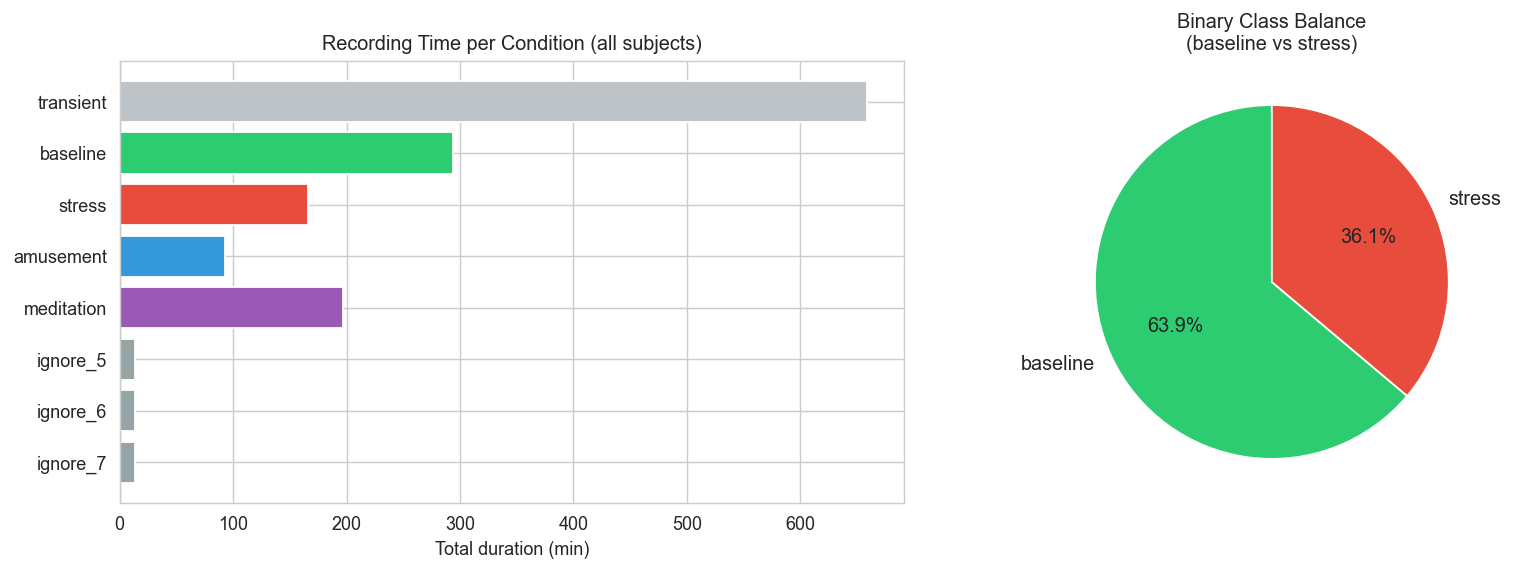

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

palette = {0: "#bdc3c7", 1: "#2ecc71", 2: "#e74c3c", 3: "#3498db", 4: "#9b59b6"}
colors  = [palette.get(r.label_id, "#95a5a6") for _, r in label_df.iterrows()]

axes[0].barh(label_df["label_name"], label_df["duration_min"], color=colors)
axes[0].set_xlabel("Total duration (min)")
axes[0].set_title("Recording Time per Condition (all subjects)")
axes[0].invert_yaxis()

binary_mins = {
    "baseline": counts.get(1, 0) / CHEST_SR / 60,
    "stress":   counts.get(2, 0) / CHEST_SR / 60,
}
axes[1].pie(
    binary_mins.values(), labels=binary_mins.keys(),
    autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"],
    startangle=90, textprops={"fontsize": 11},
)
axes[1].set_title("Binary Class Balance\n(baseline vs stress)")

plt.tight_layout()
plt.show()


### 3.2  Raw wrist signals — Apple Watch channels only

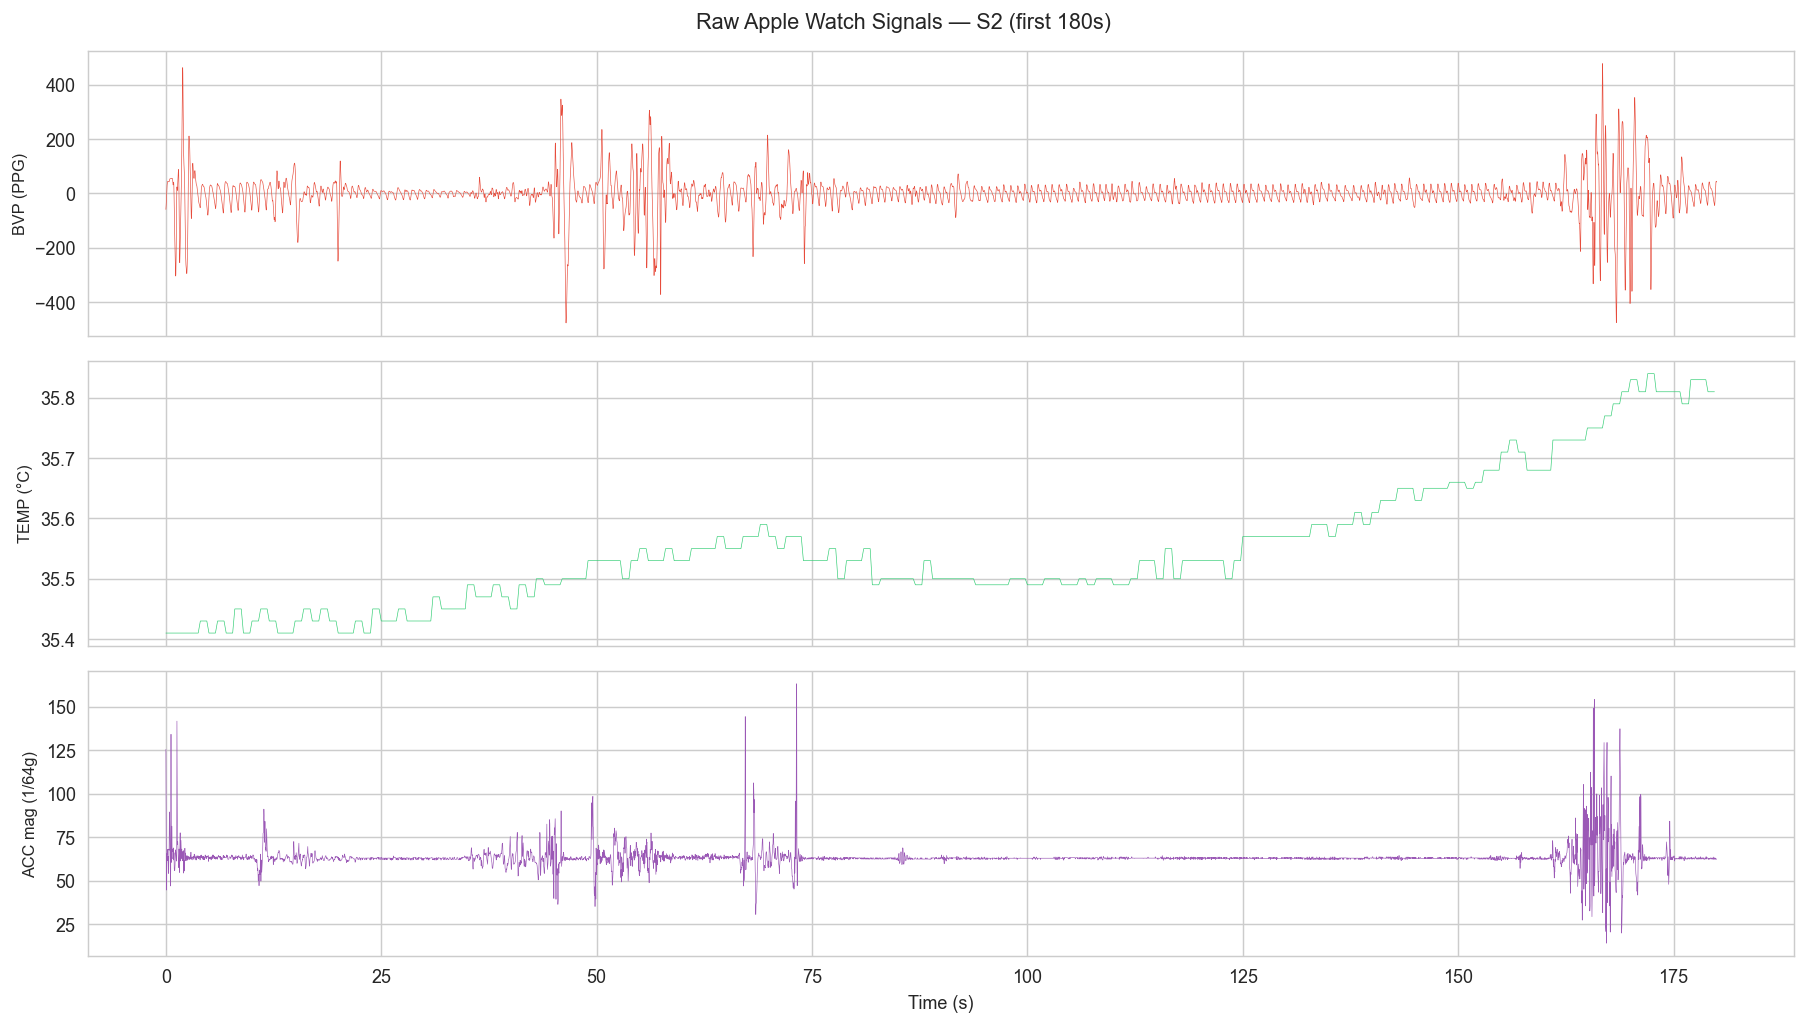

In [7]:
def plot_raw_wrist(sub: dict, seconds: int = 180):
    """Plot first `seconds` of Apple Watch-compatible modalities (no EDA)."""
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    sid = sub["sid"]

    specs = [
        ("BVP (PPG)",       sub["BVP"],                                WRIST_SR["BVP"],  "#e74c3c"),
        ("TEMP (°C)",       sub["TEMP"],                               WRIST_SR["TEMP"], "#2ecc71"),
        ("ACC mag (1/64g)", np.linalg.norm(sub["ACC"], axis=1),        WRIST_SR["ACC"],  "#9b59b6"),
    ]

    for ax, (name, sig, sr, col) in zip(axes, specs):
        n = min(len(sig), sr * seconds)
        t = np.arange(n) / sr
        ax.plot(t, sig[:n], color=col, linewidth=0.35, rasterized=True)
        ax.set_ylabel(name, fontsize=9)

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Raw Apple Watch Signals — {sid} (first {seconds}s)", fontsize=12)
    plt.tight_layout()
    plt.show()


plot_raw_wrist(subjects[VALID_SIDS[0]])


### 3.3  Per-subject summary

In [8]:
rows = []
for sid, sub in subjects.items():
    lbl = sub["label_700"]
    rows.append({
        "subject":       sid,
        "total_min":     len(lbl) / CHEST_SR / 60,
        "baseline_min":  np.sum(lbl == 1) / CHEST_SR / 60,
        "stress_min":    np.sum(lbl == 2) / CHEST_SR / 60,
        "BVP_μ":   sub["BVP"].mean(),
        "BVP_σ":   sub["BVP"].std(),
        "TEMP_μ":  sub["TEMP"].mean(),
        "TEMP_σ":  sub["TEMP"].std(),
    })

stats_df = pd.DataFrame(rows).round(2)
stats_df


,subject,total_min,baseline_min,stress_min,BVP_μ,BVP_σ,TEMP_μ,TEMP_σ
0,S2,101.32,19.07,10.25,-0.00,75.870003,34.389999,1.05
1,S3,108.22,19.00,10.67,-0.00,30.340000,31.770000,0.96
2,S4,107.05,19.30,10.58,0.01,75.769997,32.439999,0.56
3,S5,104.30,19.97,10.75,-0.00,125.769997,33.560001,1.66
4,S6,117.85,19.67,10.83,0.00,48.869999,32.180000,1.22
5,S7,87.30,19.77,10.67,0.00,36.919998,32.900002,1.17
6,S8,91.10,19.48,11.17,-0.00,74.989998,32.910000,0.67
7,S9,87.05,19.67,10.75,-0.00,60.419998,32.689999,1.25
8,S10,91.60,19.67,12.08,0.00,46.250000,33.430000,0.97
9,S11,87.22,19.67,11.33,0.00,42.020000,32.840000,1.17


## 4 — Preprocessing Pipeline

| Step | Detail |
|---|---|
| **Unit conversion** | ACC from 1/64 g → g |
| **Bandpass filter** | BVP: 4th-order Butterworth 0.5–8 Hz |
| **Resample** | All channels → 32 Hz |
| **Label downsample** | 700 Hz → 32 Hz (nearest-neighbour) |
| **Filter labels** | Keep baseline (1) & stress (2); remap to 0 / 1 |
| **Z-score normalise** | Per-subject, per-channel |
| **Segment** | 30 s windows (960 samples) / 15 s overlap |
| **Window purity** | Reject windows spanning multiple labels |

**Note:** EDA is excluded — only 5 channels for Apple Watch compatibility.


In [9]:
# ══════════════════════════════════════════════════════════════
#  Preprocessing helpers
# ══════════════════════════════════════════════════════════════

def bandpass(sig, low, high, sr, order=4):
    """Zero-phase Butterworth bandpass filter."""
    nyq = sr / 2.0
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, sig).astype(np.float32)


def resample_to(sig, orig_sr, target_sr):
    """Resample 1-D or 2-D array to a new sampling rate."""
    if orig_sr == target_sr:
        return sig
    new_len = int(len(sig) * target_sr / orig_sr)
    if sig.ndim == 1:
        return resample(sig, new_len).astype(np.float32)
    return np.column_stack(
        [resample(sig[:, c], new_len).astype(np.float32) for c in range(sig.shape[1])]
    )


def downsample_labels(labels, target_sr, src_sr=700):
    """Nearest-neighbour downsample of label array."""
    ratio = src_sr / target_sr
    idx = np.round(np.arange(0, len(labels), ratio)).astype(int)
    idx = idx[idx < len(labels)]
    return labels[idx]


def make_windows(data, labels, win_len, step):
    """Slide a fixed-length window; keep only pure-label windows."""
    X_list, y_list = [], []
    for start in range(0, len(data) - win_len + 1, step):
        seg_lbl = labels[start : start + win_len]
        uniq = np.unique(seg_lbl)
        if len(uniq) != 1:
            continue
        raw_label = int(uniq[0])
        if raw_label not in BINARY_MAP:
            continue
        X_list.append(data[start : start + win_len])
        y_list.append(BINARY_MAP[raw_label])

    if len(X_list) == 0:
        return np.empty((0, win_len, data.shape[1])), np.empty((0,), dtype=int)
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int64)


print("Preprocessing helpers defined ✓")


Preprocessing helpers defined ✓


### 4.1  Run the pipeline (Apple Watch channels only)

In [10]:
all_X, all_y, all_sid = [], [], []

for sid, sub in subjects.items():
    print(f"{sid} ", end="")

    # 1. Unit conversion: ACC 1/64g → g
    acc_g = sub["ACC"] / 64.0

    # 2. Bandpass BVP at native 64 Hz
    bvp_filt = bandpass(sub["BVP"], BVP_LOW_HZ, BVP_HIGH_HZ, sr=WRIST_SR["BVP"])

    # 3. Resample every channel → TARGET_SR (32 Hz)
    bvp_32  = resample_to(bvp_filt,   WRIST_SR["BVP"],  TARGET_SR)
    temp_32 = resample_to(sub["TEMP"], WRIST_SR["TEMP"], TARGET_SR)
    acc_32  = resample_to(acc_g,       WRIST_SR["ACC"],  TARGET_SR)   # (N, 3)
    # EDA intentionally skipped — not on Apple Watch

    # 4. Downsample labels 700 → 32 Hz
    lbl_32 = downsample_labels(sub["label_700"], TARGET_SR)

    # 5. Trim to shortest array
    n = min(len(bvp_32), len(temp_32), len(acc_32), len(lbl_32))
    bvp_32  = bvp_32[:n]
    temp_32 = temp_32[:n]
    acc_32  = acc_32[:n]
    lbl_32  = lbl_32[:n]

    # 6. Stack Apple Watch channels → (N, 5):  BVP, TEMP, ACC_x, ACC_y, ACC_z
    data = np.column_stack([bvp_32, temp_32, acc_32])

    # 7. Per-subject Z-score normalisation
    mu  = data.mean(axis=0)
    std = data.std(axis=0) + 1e-8
    data = ((data - mu) / std).astype(np.float32)

    # 8. Segment into windows
    X_s, y_s = make_windows(data, lbl_32, WINDOW_LEN, STEP_LEN)

    n_b  = int((y_s == 0).sum())
    n_s  = int((y_s == 1).sum())
    print(f"→ {len(y_s)} windows  (baseline={n_b}, stress={n_s})")

    all_X.append(X_s)
    all_y.append(y_s)
    all_sid.extend([sid] * len(y_s))

# Concatenate across subjects
X    = np.concatenate(all_X, axis=0)      # (N_total, 960, 5)
y    = np.concatenate(all_y, axis=0)      # (N_total,)
sids = np.array(all_sid)

print(f"\n{'═'*55}")
print(f"  Total windows : {len(y)}")
print(f"  X shape       : {X.shape}   ({X.nbytes/1e6:.1f} MB)")
print(f"  Channels      : {APPLE_WATCH_CHANNELS}")
print(f"  baseline (0)  : {(y==0).sum()}")
print(f"  stress   (1)  : {(y==1).sum()}")
print(f"  ratio         : {(y==0).sum()/len(y):.1%} / {(y==1).sum()/len(y):.1%}")
print(f"{'═'*55}")


S2 → 113 windows  (baseline=74, stress=39)
S3 → 115 windows  (baseline=74, stress=41)
S4 → 116 windows  (baseline=75, stress=41)
S5 → 119 windows  (baseline=78, stress=41)
S6 → 119 windows  (baseline=77, stress=42)
S7 → 118 windows  (baseline=77, stress=41)
S8 → 119 windows  (baseline=76, stress=43)
S9 → 117 windows  (baseline=76, stress=41)
S10 → 123 windows  (baseline=76, stress=47)
S11 → 120 windows  (baseline=77, stress=43)
S13 → 119 windows  (baseline=77, stress=42)
S14 → 120 windows  (baseline=77, stress=43)
S15 → 120 windows  (baseline=76, stress=44)
S16 → 120 windows  (baseline=77, stress=43)
S17 → 122 windows  (baseline=76, stress=46)

═══════════════════════════════════════════════════════
  Total windows : 1780
  X shape       : (1780, 960, 5)   (34.2 MB)
  Channels      : ['BVP', 'TEMP', 'ACC_x', 'ACC_y', 'ACC_z']
  baseline (0)  : 1143
  stress   (1)  : 637
  ratio         : 64.2% / 35.8%
═══════════════════════════════════════════════════════


### 4.2  Preprocessed window comparison

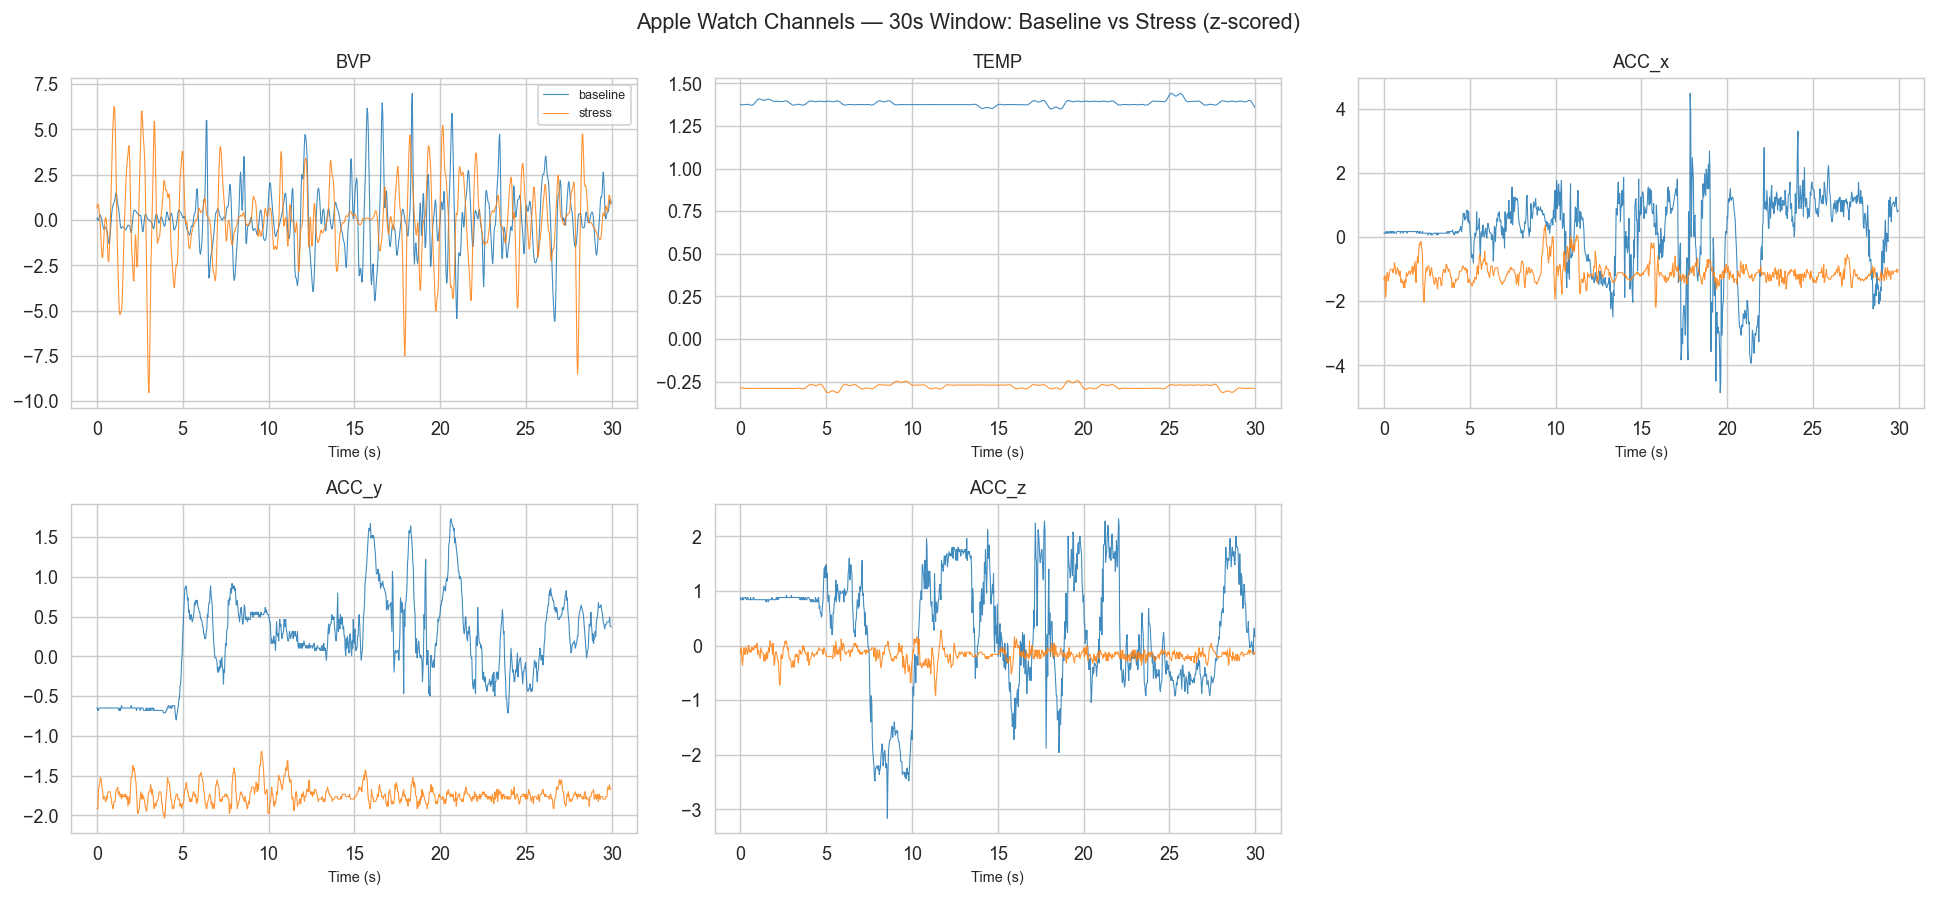

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
t = np.arange(WINDOW_LEN) / TARGET_SR

idx_b = np.where(y == 0)[0][0]
idx_s = np.where(y == 1)[0][0]

for i, (ax, name) in enumerate(zip(axes.flat[:N_CHANNELS], APPLE_WATCH_CHANNELS)):
    ax.plot(t, X[idx_b, :, i], label="baseline", linewidth=0.6, alpha=0.85)
    ax.plot(t, X[idx_s, :, i], label="stress",   linewidth=0.6, alpha=0.85)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Time (s)", fontsize=8)
    if i == 0:
        ax.legend(fontsize=7)

# hide the unused 6th subplot
axes.flat[-1].set_visible(False)

fig.suptitle("Apple Watch Channels — 30s Window: Baseline vs Stress (z-scored)", fontsize=12)
plt.tight_layout()
plt.show()


### 4.3  Inter-channel correlation

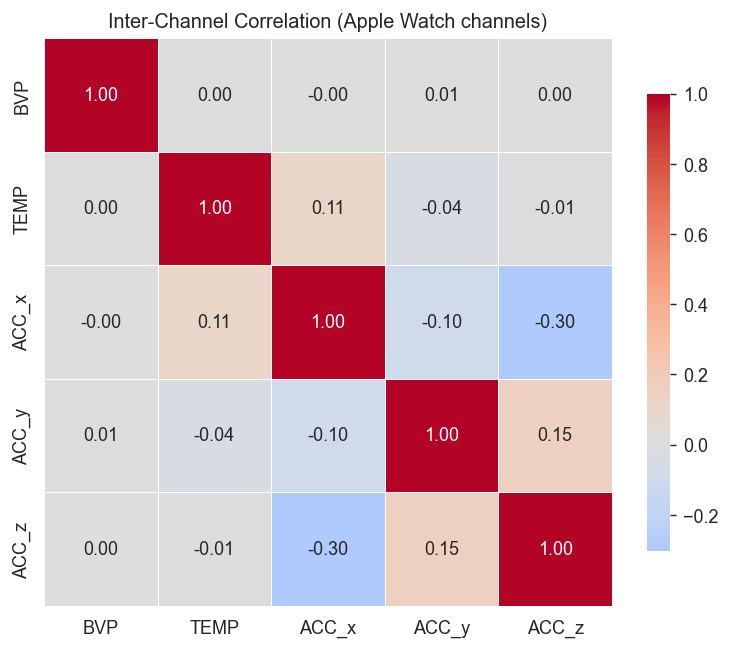

In [12]:
X_flat = X.mean(axis=1)   # (N, 5) — per-window channel means
corr = pd.DataFrame(X_flat, columns=APPLE_WATCH_CHANNELS).corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Inter-Channel Correlation (Apple Watch channels)")
plt.tight_layout()
plt.show()


## 5 — Class-Imbalance Handling

In [13]:
# Compute class weights for weighted BCE (used during training)
n0, n1 = (y == 0).sum(), (y == 1).sum()
w0 = len(y) / (2 * n0)
w1 = len(y) / (2 * n1)
print(f"Class weights for BCE:  w_baseline = {w0:.3f},  w_stress = {w1:.3f}")
print(f"  (Baseline dominates by {n0/n1:.1f}×; weights compensate)")


Class weights for BCE:  w_baseline = 0.779,  w_stress = 1.397
  (Baseline dominates by 1.8×; weights compensate)


## 6 — Subject-Independent Split

60 / 20 / 20 split by subject — no data leakage.


In [14]:
unique_sids = sorted(np.unique(sids))
n_sub = len(unique_sids)

rng = np.random.default_rng(42)
shuffled = rng.permutation(unique_sids)

n_test = max(1, int(0.2 * n_sub))
n_val  = max(1, int(0.2 * n_sub))

test_sids  = set(shuffled[:n_test])
val_sids   = set(shuffled[n_test : n_test + n_val])
train_sids = set(shuffled[n_test + n_val :])

print(f"Train subjects ({len(train_sids)}): {sorted(train_sids)}")
print(f"Val   subjects ({len(val_sids)}):  {sorted(val_sids)}")
print(f"Test  subjects ({len(test_sids)}):  {sorted(test_sids)}")


def split_by_subjects(X, y, sids, subject_set):
    mask = np.isin(sids, list(subject_set))
    return X[mask], y[mask]


X_train, y_train = split_by_subjects(X, y, sids, train_sids)
X_val,   y_val   = split_by_subjects(X, y, sids, val_sids)
X_test,  y_test  = split_by_subjects(X, y, sids, test_sids)

for name, Xs, ys in [("Train", X_train, y_train),
                      ("Val",   X_val,   y_val),
                      ("Test",  X_test,  y_test)]:
    n_b = int((ys == 0).sum())
    n_s = int((ys == 1).sum())
    print(f"{name:5s}  →  {len(ys):5d} windows  |  baseline={n_b}  stress={n_s}")


Train subjects (9): [np.str_('S11'), np.str_('S13'), np.str_('S15'), np.str_('S16'), np.str_('S3'), np.str_('S5'), np.str_('S7'), np.str_('S8'), np.str_('S9')]
Val   subjects (3):  [np.str_('S10'), np.str_('S14'), np.str_('S6')]
Test  subjects (3):  [np.str_('S17'), np.str_('S2'), np.str_('S4')]
Train  →   1067 windows  |  baseline=688  stress=379
Val    →    362 windows  |  baseline=230  stress=132
Test   →    351 windows  |  baseline=225  stress=126


## 7 — PyTorch Dataset & DataLoaders

In [15]:
def to_tensors(X, y):
    """Convert numpy arrays to channels-first PyTorch tensors."""
    Xt = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)  # (N, C, T)
    yt = torch.tensor(y, dtype=torch.long)
    return Xt, yt


X_tr, y_tr = to_tensors(X_train, y_train)
X_v,  y_v  = to_tensors(X_val,   y_val)
X_te, y_te = to_tensors(X_test,  y_test)

train_ds = TensorDataset(X_tr, y_tr)
val_ds   = TensorDataset(X_v,  y_v)
test_ds  = TensorDataset(X_te, y_te)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}  |  Val: {len(val_loader)}  |  Test: {len(test_loader)}")
print(f"Tensor shape  — X_tr: {X_tr.shape}  (batch, {N_CHANNELS} ch, {WINDOW_LEN} samples)")


Train batches: 16  |  Val: 6  |  Test: 6
Tensor shape  — X_tr: torch.Size([1067, 5, 960])  (batch, 5 ch, 960 samples)


## 8 — Model A: EdgeStressNet (1D-DSC + BiGRU)

Lightweight architecture for on-device watchOS inference:

1. **Depthwise separable 1D convolutions** — local temporal features per channel (~9× fewer params)  
2. **Bidirectional GRU** — short- and long-range temporal dynamics  
3. **Attention pooling** — learns which time steps matter  
4. **Linear head** — binary output  

**Adapted for 5 Apple Watch channels** (was 6 in the original with EDA).


In [16]:
class DepthwiseSepConv1d(nn.Module):
    """Depthwise separable 1D convolution: depthwise + pointwise."""
    def __init__(self, in_ch, out_ch, kernel_size, padding="same"):
        super().__init__()
        self.depthwise = nn.Conv1d(
            in_ch, in_ch, kernel_size, padding=padding, groups=in_ch, bias=False
        )
        self.pointwise = nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm1d(out_ch)

    def forward(self, x):
        return F.relu(self.bn(self.pointwise(self.depthwise(x))))


class AttentionPool(nn.Module):
    """Learnable attention pooling over the time dimension."""
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return (x * w).sum(dim=1)


class EdgeStressNet(nn.Module):
    """
    Lightweight 1D-DSC + BiGRU for Apple Watch stress detection.

    Input:  (B, 5, 960)  — 5 Apple Watch channels @ 32 Hz × 30s
    Output: (B, 2)       — [baseline, stress] logits
    """
    def __init__(self, in_channels=5, gru_hidden=48, n_classes=2, dropout=0.3):
        super().__init__()

        self.conv = nn.Sequential(
            DepthwiseSepConv1d(in_channels, 32, kernel_size=7),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),

            DepthwiseSepConv1d(32, 64, kernel_size=5),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),

            DepthwiseSepConv1d(64, 64, kernel_size=3),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
        )

        self.gru = nn.GRU(
            input_size=64,
            hidden_size=gru_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        self.attn_pool = AttentionPool(gru_hidden * 2)
        self.head = nn.Sequential(
            nn.LayerNorm(gru_hidden * 2),
            nn.Dropout(dropout),
            nn.Linear(gru_hidden * 2, n_classes),
        )

    def forward(self, x):
        h = self.conv(x)            # (B, 64, T')
        h = h.permute(0, 2, 1)      # (B, T', 64)
        h, _ = self.gru(h)          # (B, T', 96)
        h = self.attn_pool(h)       # (B, 96)
        return self.head(h)          # (B, 2)


model_a = EdgeStressNet(in_channels=N_CHANNELS).to(DEVICE)
n_params_a = sum(p.numel() for p in model_a.parameters() if p.requires_grad)

print(f"Model A (EdgeStressNet — Apple Watch)")
print(f"  Input channels : {N_CHANNELS}  {APPLE_WATCH_CHANNELS}")
print(f"  Parameters     : {n_params_a:,}")
print(f"  Size (est)     : {n_params_a * 4 / 1024:.1f} KB (float32)")

dummy = torch.randn(2, N_CHANNELS, WINDOW_LEN).to(DEVICE)
out = model_a(dummy)
print(f"  Output         : {out.shape}")


Model A (EdgeStressNet — Apple Watch)
  Input channels : 5  ['BVP', 'TEMP', 'ACC_x', 'ACC_y', 'ACC_z']
  Parameters     : 40,326
  Size (est)     : 157.5 KB (float32)
  Output         : torch.Size([2, 2])


## 9 — Model B: PatchTST (Transformer Baseline)

Full-accuracy baseline. Same channel restriction (5 ch), but much larger.


In [17]:
class PatchEmbedding(nn.Module):
    """Split a single-channel time series into patches and project to d_model."""
    def __init__(self, patch_size, d_model, seq_len, dropout=0.1):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches  = seq_len // patch_size
        self.proj       = nn.Linear(patch_size, d_model)
        self.pos_embed  = nn.Parameter(torch.randn(1, self.n_patches, d_model) * 0.02)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x):
        B, T = x.shape
        x = x[:, :self.n_patches * self.patch_size]
        x = x.reshape(B, self.n_patches, self.patch_size)
        x = self.proj(x) + self.pos_embed
        return self.dropout(x)


class PatchTST(nn.Module):
    """
    PatchTST for multivariate time-series binary classification.
    Adapted for 5 Apple Watch channels.
    """
    def __init__(self, in_channels=5, seq_len=960, patch_size=30,
                 d_model=64, n_heads=4, n_layers=3, d_ff=128,
                 dropout=0.2, n_classes=2):
        super().__init__()
        self.in_channels = in_channels

        self.patch_embeds = nn.ModuleList([
            PatchEmbedding(patch_size, d_model, seq_len, dropout)
            for _ in range(in_channels)
        ])

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model * in_channels),
            nn.Dropout(dropout),
            nn.Linear(d_model * in_channels, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        channel_reps = []
        for i in range(self.in_channels):
            tok = self.patch_embeds[i](x[:, i, :])
            enc = self.encoder(tok)
            rep = enc.mean(dim=1)
            channel_reps.append(rep)

        h = torch.cat(channel_reps, dim=-1)
        return self.head(h)


model_b = PatchTST(in_channels=N_CHANNELS, seq_len=WINDOW_LEN).to(DEVICE)
n_params_b = sum(p.numel() for p in model_b.parameters() if p.requires_grad)

print(f"Model B (PatchTST — Apple Watch)")
print(f"  Parameters : {n_params_b:,}")
print(f"  Size (est) : {n_params_b * 4 / 1024:.1f} KB (float32)")
print(f"  Output     : {model_b(dummy).shape}")
print(f"\nParam ratio  : PatchTST is {n_params_b / n_params_a:.1f}× larger than EdgeStressNet")


Model B (PatchTST — Apple Watch)
  Parameters : 141,890
  Size (est) : 554.3 KB (float32)
  Output     : torch.Size([2, 2])

Param ratio  : PatchTST is 3.5× larger than EdgeStressNet


## 10 — Training Engine & Train Both Models

In [18]:
class EarlyStopping:
    def __init__(self, patience=10, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best = -np.inf if mode == "max" else np.inf
        self.counter = 0
        self.best_state = None

    def step(self, metric, model):
        improved = (metric > self.best) if self.mode == "max" else (metric < self.best)
        if improved:
            self.best = metric
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False
        self.counter += 1
        return self.counter >= self.patience


def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
            logits = model(xb)
            loss = criterion(logits, yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * len(yb)
        n += len(yb)
    return total_loss / n


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        all_probs.append(probs)
        all_labels.append(yb.numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "y_true": y_true, "y_prob": y_prob, "y_pred": y_pred,
        "acc":   accuracy_score(y_true, y_pred),
        "f1":    f1_score(y_true, y_pred),
        "auroc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.0,
        "prec":  precision_score(y_true, y_pred, zero_division=0),
        "rec":   recall_score(y_true, y_pred, zero_division=0),
    }


def train_model(model, name, epochs=EPOCHS, lr=LR, patience=PATIENCE):
    print(f"\n{'═'*60}")
    print(f"  Training: {name}")
    print(f"{'═'*60}")

    weights = torch.tensor([w0, w1], dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler    = torch.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
    stopper   = EarlyStopping(patience=patience, mode="max")

    history = {"epoch": [], "train_loss": [], "val_acc": [], "val_f1": [], "val_auroc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        scheduler.step()
        val_metrics = evaluate(model, val_loader)
        elapsed = time.time() - t0

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_metrics["acc"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_auroc"].append(val_metrics["auroc"])

        if epoch % 5 == 0 or epoch == 1:
            print(
                f"  Epoch {epoch:3d}/{epochs}  |  loss={train_loss:.4f}  "
                f"val_acc={val_metrics['acc']:.3f}  val_f1={val_metrics['f1']:.3f}  "
                f"val_auroc={val_metrics['auroc']:.3f}  ({elapsed:.1f}s)"
            )

        if stopper.step(val_metrics["auroc"], model):
            print(f"  → Early stopping at epoch {epoch}  (best AUROC={stopper.best:.4f})")
            break

    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)

    return pd.DataFrame(history)


print("Training engine ready ✓")


Training engine ready ✓


In [19]:
# ── Train Model A (EdgeStressNet) ──────────────────────────────
model_a = EdgeStressNet(in_channels=N_CHANNELS).to(DEVICE)
history_a = train_model(model_a, "Model A — EdgeStressNet (Apple Watch)")



════════════════════════════════════════════════════════════
  Training: Model A — EdgeStressNet (Apple Watch)
════════════════════════════════════════════════════════════
  Epoch   1/60  |  loss=0.4895  val_acc=0.417  val_f1=0.532  val_auroc=0.529  (4.0s)
  Epoch   5/60  |  loss=0.2650  val_acc=0.586  val_f1=0.554  val_auroc=0.620  (3.9s)
  Epoch  10/60  |  loss=0.1963  val_acc=0.588  val_f1=0.505  val_auroc=0.585  (4.0s)
  Epoch  15/60  |  loss=0.1469  val_acc=0.638  val_f1=0.576  val_auroc=0.622  (3.9s)
  → Early stopping at epoch 19  (best AUROC=0.6339)


In [20]:
# ── Train Model B (PatchTST) ──────────────────────────────────
model_b = PatchTST(in_channels=N_CHANNELS, seq_len=WINDOW_LEN).to(DEVICE)
history_b = train_model(model_b, "Model B — PatchTST (Apple Watch)")



════════════════════════════════════════════════════════════
  Training: Model B — PatchTST (Apple Watch)
════════════════════════════════════════════════════════════
  Epoch   1/60  |  loss=0.4518  val_acc=0.575  val_f1=0.536  val_auroc=0.632  (1.6s)
  Epoch   5/60  |  loss=0.2036  val_acc=0.588  val_f1=0.521  val_auroc=0.678  (1.6s)
  Epoch  10/60  |  loss=0.0857  val_acc=0.691  val_f1=0.588  val_auroc=0.755  (1.6s)
  Epoch  15/60  |  loss=0.0423  val_acc=0.688  val_f1=0.598  val_auroc=0.776  (1.6s)
  Epoch  20/60  |  loss=0.0228  val_acc=0.760  val_f1=0.688  val_auroc=0.861  (1.6s)
  Epoch  25/60  |  loss=0.0099  val_acc=0.691  val_f1=0.624  val_auroc=0.812  (1.6s)
  Epoch  30/60  |  loss=0.0065  val_acc=0.743  val_f1=0.657  val_auroc=0.837  (1.6s)
  → Early stopping at epoch 31  (best AUROC=0.8751)


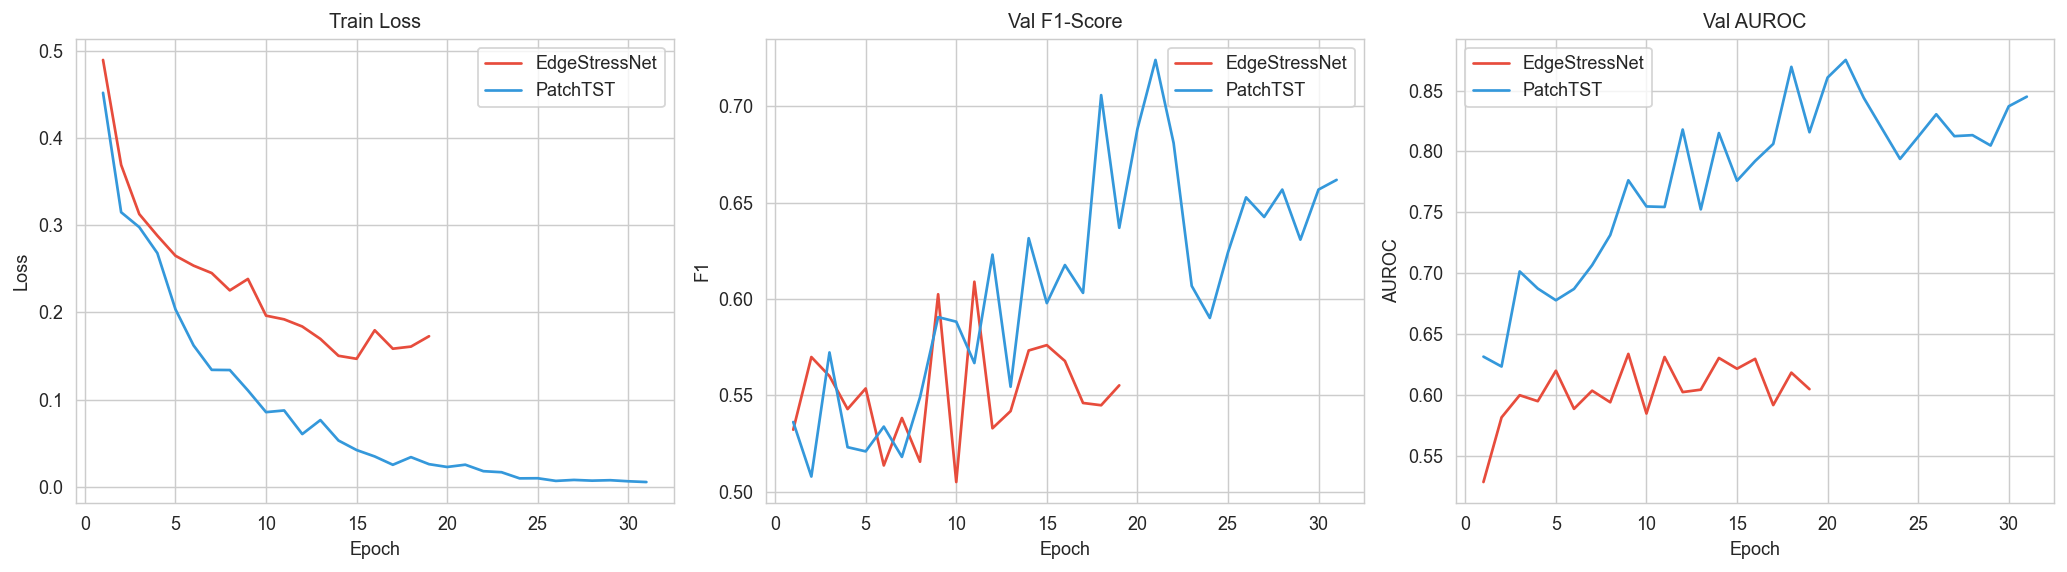

In [21]:
# ── Training curves ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for hist, name, color in [(history_a, "EdgeStressNet", "#e74c3c"),
                           (history_b, "PatchTST", "#3498db")]:
    axes[0].plot(hist["epoch"], hist["train_loss"], label=name, color=color)
    axes[1].plot(hist["epoch"], hist["val_f1"],     label=name, color=color)
    axes[2].plot(hist["epoch"], hist["val_auroc"],  label=name, color=color)

axes[0].set_title("Train Loss");      axes[0].set_ylabel("Loss")
axes[1].set_title("Val F1-Score");     axes[1].set_ylabel("F1")
axes[2].set_title("Val AUROC");        axes[2].set_ylabel("AUROC")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.show()


## 11 — Evaluation on Held-Out Test Set

In [22]:
results_a = evaluate(model_a, test_loader)
results_b = evaluate(model_b, test_loader)

metrics_table = pd.DataFrame({
    "Metric":  ["Accuracy", "F1-Score", "AUROC", "Precision", "Sensitivity (Recall)"],
    "EdgeStressNet": [f"{results_a[k]:.4f}" for k in ["acc","f1","auroc","prec","rec"]],
    "PatchTST":      [f"{results_b[k]:.4f}" for k in ["acc","f1","auroc","prec","rec"]],
})
metrics_table


,Metric,EdgeStressNet,PatchTST
0,Accuracy,0.9430,0.8291
1,F1-Score,0.9174,0.7000
2,AUROC,0.8987,0.9792
3,Precision,0.9569,0.9459
4,Sensitivity (Recall),0.8810,0.5556


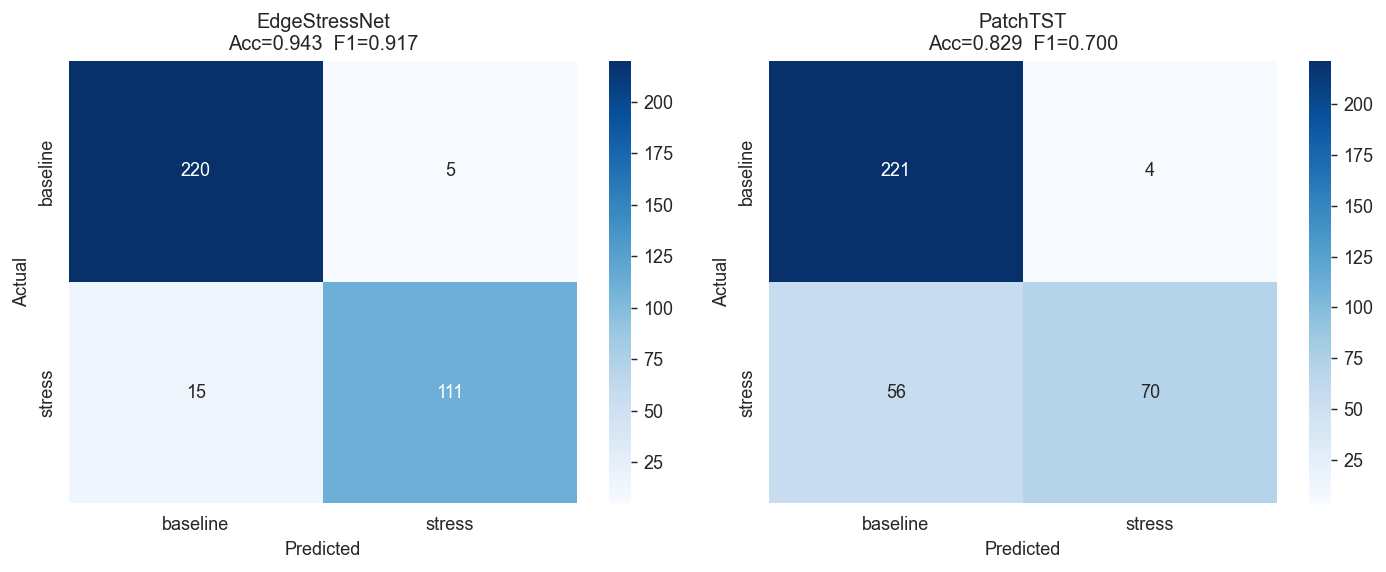

In [23]:
# ── Confusion Matrices ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, res, name in [(axes[0], results_a, "EdgeStressNet"),
                       (axes[1], results_b, "PatchTST")]:
    cm = confusion_matrix(res["y_true"], res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["baseline", "stress"],
                yticklabels=["baseline", "stress"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{name}\nAcc={res['acc']:.3f}  F1={res['f1']:.3f}")

plt.tight_layout()
plt.show()


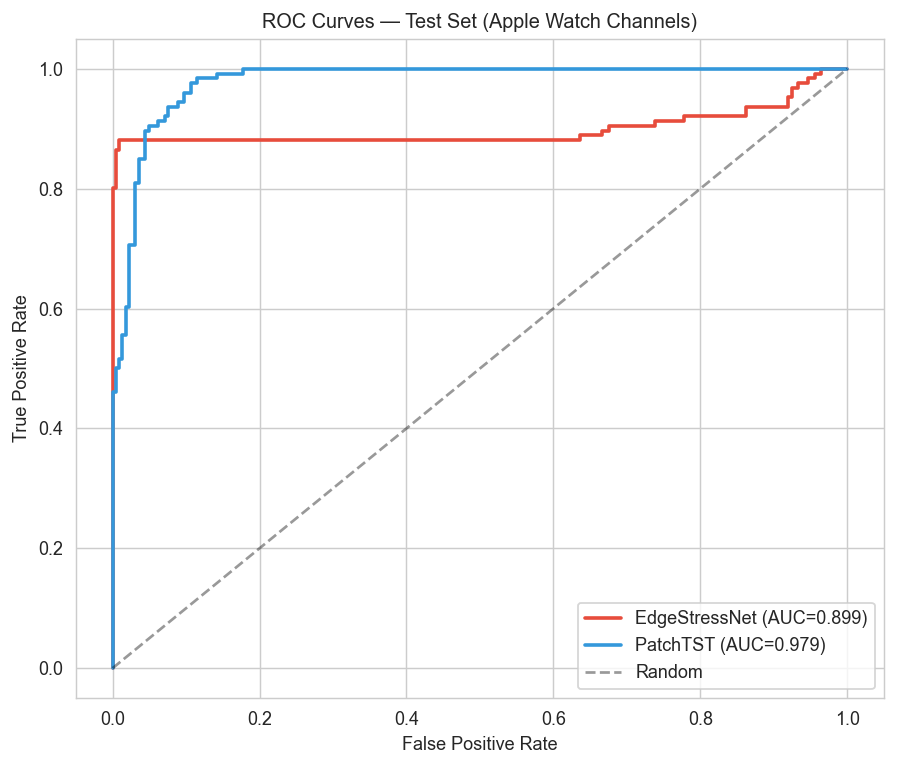

In [24]:
# ── ROC Curves ─────────────────────────────────────────────────
plt.figure(figsize=(7, 6))

for res, name, color in [(results_a, "EdgeStressNet", "#e74c3c"),
                          (results_b, "PatchTST", "#3498db")]:
    fpr, tpr, _ = roc_curve(res["y_true"], res["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auroc']:.3f})", color=color, linewidth=2)

plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Test Set (Apple Watch Channels)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [25]:
# ── Classification Reports ─────────────────────────────────────
for name, res in [("Model A — EdgeStressNet", results_a), ("Model B — PatchTST", results_b)]:
    print("=" * 50)
    print(name)
    print("=" * 50)
    print(classification_report(res["y_true"], res["y_pred"],
                                target_names=["baseline", "stress"]))


Model A — EdgeStressNet
              precision    recall  f1-score   support

    baseline       0.94      0.98      0.96       225
      stress       0.96      0.88      0.92       126

    accuracy                           0.94       351
   macro avg       0.95      0.93      0.94       351
weighted avg       0.94      0.94      0.94       351

Model B — PatchTST
              precision    recall  f1-score   support

    baseline       0.80      0.98      0.88       225
      stress       0.95      0.56      0.70       126

    accuracy                           0.83       351
   macro avg       0.87      0.77      0.79       351
weighted avg       0.85      0.83      0.82       351



## 12 — Edge Optimisation

| Technique | What it does |
|---|---|
| **Structured pruning** | Zero out entire Conv1d filters (20–50%) to reduce FLOPs |
| **Dynamic INT8 quantisation** | 8-bit weights → ~4× size reduction |
| **ONNX export** | Portable format, verifiable with ONNX Runtime |


In [26]:
# ── Utility: model size & latency ──────────────────────────────

def model_size_kb(model):
    total_bytes = sum(p.nelement() * p.element_size() for p in model.parameters())
    total_bytes += sum(b.nelement() * b.element_size() for b in model.buffers())
    return total_bytes / 1024


def measure_latency_ms(model, input_tensor, n_runs=100, warmup=10):
    model_cpu = copy.deepcopy(model).cpu().eval()
    x = input_tensor.cpu()

    with torch.no_grad():
        for _ in range(warmup):
            _ = model_cpu(x)

    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            t0 = time.perf_counter()
            _ = model_cpu(x)
            times.append((time.perf_counter() - t0) * 1000)

    return np.mean(times), np.std(times)


dummy_single = torch.randn(1, N_CHANNELS, WINDOW_LEN)

size_a_orig = model_size_kb(model_a)
lat_a_orig, lat_a_std = measure_latency_ms(model_a, dummy_single)

print(f"Model A (original float32)")
print(f"  Size    : {size_a_orig:.1f} KB")
print(f"  Latency : {lat_a_orig:.2f} ± {lat_a_std:.2f} ms  (CPU, batch=1)")


Model A (original float32)
  Size    : 158.8 KB
  Latency : 2.72 ± 0.05 ms  (CPU, batch=1)


In [27]:
# ── 12.1  Structured Pruning ───────────────────────────────────
import torch.nn.utils.prune as prune

def apply_structured_pruning(model, amount=0.3):
    model_pruned = copy.deepcopy(model)
    for name, module in model_pruned.named_modules():
        if isinstance(module, nn.Conv1d):
            prune.ln_structured(module, name="weight", amount=amount, n=1, dim=0)
            prune.remove(module, "weight")
    return model_pruned


prune_levels = [0.2, 0.3]
pruned_results = {}

for amt in prune_levels:
    m_pruned = apply_structured_pruning(model_a, amount=amt).to(DEVICE)
    res = evaluate(m_pruned, test_loader)
    size_kb = model_size_kb(m_pruned)
    lat, _ = measure_latency_ms(m_pruned, dummy_single)

    nonzero = sum((p != 0).sum().item() for p in m_pruned.parameters())
    total   = sum(p.numel() for p in m_pruned.parameters())
    sparsity = 1 - nonzero / total

    pruned_results[f"pruned_{int(amt*100)}%"] = {
        "acc": res["acc"], "f1": res["f1"], "auroc": res["auroc"],
        "size_kb": size_kb, "latency_ms": lat, "sparsity": sparsity,
    }
    print(f"  Pruning {amt:.0%}  →  acc={res['acc']:.3f}  f1={res['f1']:.3f}  "
          f"auroc={res['auroc']:.3f}  sparsity={sparsity:.1%}  latency={lat:.2f}ms")


  Pruning 20%  →  acc=0.855  f1=0.746  auroc=0.971  sparsity=3.4%  latency=2.71ms
  Pruning 30%  →  acc=0.795  f1=0.600  auroc=1.000  sparsity=4.9%  latency=2.72ms


In [28]:
# ── 12.2  Dynamic INT8 Quantisation ────────────────────────────
torch.backends.quantized.engine = 'qnnpack'
model_a_cpu = copy.deepcopy(model_a).cpu().eval()

model_a_quant = torch.ao.quantization.quantize_dynamic(
    model_a_cpu,
    {nn.Linear, nn.GRU},
    dtype=torch.qint8,
)

model_a_quant.eval()
quant_preds, quant_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model_a_quant(xb.cpu())
        probs = torch.softmax(logits, dim=1)[:, 1].numpy()
        quant_preds.append(probs)
        quant_labels.append(yb.numpy())

y_true_q = np.concatenate(quant_labels)
y_prob_q = np.concatenate(quant_preds)
y_pred_q = (y_prob_q >= 0.5).astype(int)

quant_acc   = accuracy_score(y_true_q, y_pred_q)
quant_f1    = f1_score(y_true_q, y_pred_q)
quant_auroc = roc_auc_score(y_true_q, y_prob_q) if len(np.unique(y_true_q)) > 1 else 0.0

with tempfile.NamedTemporaryFile(suffix=".pt") as f:
    torch.save(model_a_quant.state_dict(), f.name)
    quant_size_kb = os.path.getsize(f.name) / 1024

quant_lat, _ = measure_latency_ms(model_a_quant, dummy_single)

print(f"Quantised Model A (INT8)")
print(f"  Acc     : {quant_acc:.4f}")
print(f"  F1      : {quant_f1:.4f}")
print(f"  AUROC   : {quant_auroc:.4f}")
print(f"  Size    : {quant_size_kb:.1f} KB  (was {size_a_orig:.1f} KB → {size_a_orig/quant_size_kb:.1f}× smaller)")
print(f"  Latency : {quant_lat:.2f} ms  (was {lat_a_orig:.2f} ms)")


[W402 22:27:31.197312000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())


Quantised Model A (INT8)
  Acc     : 0.9430
  F1      : 0.9174
  AUROC   : 0.8986
  Size    : 80.5 KB  (was 158.8 KB → 2.0× smaller)
  Latency : 3.45 ms  (was 2.72 ms)


In [29]:
!pip install onnx onnxruntime


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [30]:
# ── 12.3  ONNX Export ──────────────────────────────────────────
onnx_path = "echo_apple_watch.onnx"

model_a_export = copy.deepcopy(model_a).cpu().eval()
dummy_onnx = torch.randn(1, N_CHANNELS, WINDOW_LEN)

torch.onnx.export(
    model_a_export,
    dummy_onnx,
    onnx_path,
    input_names=["wrist_signals"],
    output_names=["stress_logits"],
    dynamic_axes={"wrist_signals": {0: "batch"}, "stress_logits": {0: "batch"}},
    opset_version=17,
)

onnx_size_kb = os.path.getsize(onnx_path) / 1024
print(f"Exported to {onnx_path}  ({onnx_size_kb:.1f} KB)")

try:
    import onnxruntime as ort
    sess = ort.InferenceSession(onnx_path)
    ort_out = sess.run(None, {"wrist_signals": dummy_onnx.numpy()})
    pt_out  = model_a_export(dummy_onnx).detach().numpy()
    max_diff = np.abs(ort_out[0] - pt_out).max()
    print(f"ONNX Runtime verification: max diff = {max_diff:.6f}  ({'✓ OK' if max_diff < 1e-4 else '⚠ check'})")
except ImportError:
    print("onnxruntime not installed — skipping verification")


Exported to echo_apple_watch.onnx  (162.3 KB)
ONNX Runtime verification: max diff = 0.000001  (✓ OK)


## 13 — CoreML Export for Apple Watch / watchOS

Apple Watch apps use **Core ML** (`.mlmodel` / `.mlpackage`) for on-device inference.  
We convert the ONNX model → CoreML using `coremltools`.  

**watchOS deployment constraints:**  
- Max model size recommendation: **< 5 MB** (ideally < 1 MB for Watch)  
- Supported ops: CoreML supports Conv1d, GRU, Linear, BatchNorm, ReLU, Softmax  
- Inference runs on Apple Neural Engine (ANE) or CPU  
- Input: `MultiArray(Float32)` of shape `(1, 5, 960)`  


In [31]:
# ── Install coremltools if needed ──────────────────────────────
try:
    import coremltools as ct
    print(f"coremltools {ct.__version__} ✓")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "coremltools", "--break-system-packages", "-q"])
    import coremltools as ct
    print(f"coremltools {ct.__version__} installed ✓")


scikit-learn version 1.7.1 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
TensorFlow version 2.20.0 has not been tested with coremltools. You may run into unexpected errors. TensorFlow 2.12.0 is the most recent version that has been tested.
Torch version 2.8.0 has not been tested with coremltools. You may run into unexpected errors. Torch 2.7.0 is the most recent version that has been tested.


coremltools 9.0 ✓


In [32]:
# ── Convert PyTorch → CoreML ───────────────────────────────────
model_a_trace = copy.deepcopy(model_a).cpu().eval()
example_input = torch.randn(1, N_CHANNELS, WINDOW_LEN)

# Trace the model (CoreML tools works with traced models)
traced_model = torch.jit.trace(model_a_trace, example_input)

# Convert to CoreML
coreml_model = ct.convert(
    traced_model,
    inputs=[
        ct.TensorType(
            name="wrist_signals",
            shape=(1, N_CHANNELS, WINDOW_LEN),
            dtype=np.float32,
        )
    ],
    outputs=[
        ct.TensorType(name="stress_logits")
    ],
    convert_to="mlprogram",           # ML Program format (iOS 15+, watchOS 8+)
    minimum_deployment_target=ct.target.watchOS8,
)

# ── Add metadata ───────────────────────────────────────────────
coreml_model.author = "ECHO Team (Balamurugan, Rupali, Adwaith)"
coreml_model.short_description = (
    "EdgeStressNet: Real-time stress detection from Apple Watch sensors. "
    "Input: 30s window of BVP, TEMP, ACC_xyz @ 32Hz (z-scored). "
    "Output: [baseline, stress] logits."
)
coreml_model.version = "1.0.0"

# Input/output descriptions
coreml_model.input_description["wrist_signals"] = (
    "Z-scored sensor window: shape (1, 5, 960) = "
    "(batch, [BVP,TEMP,ACC_x,ACC_y,ACC_z], 30s@32Hz)"
)
coreml_model.output_description["stress_logits"] = (
    "Raw logits: [baseline_score, stress_score]. Apply softmax for probabilities."
)

# ── Save ────────────────────────────────────────────────────────
coreml_path = "EchoStressDetector.mlpackage"
coreml_model.save(coreml_path)

# Measure size
import shutil
coreml_size_bytes = sum(
    f.stat().st_size for f in __import__('pathlib').Path(coreml_path).rglob('*') if f.is_file()
)
coreml_size_kb = coreml_size_bytes / 1024

print(f"\nCoreML model saved: {coreml_path}")
print(f"  Size           : {coreml_size_kb:.1f} KB")
print(f"  Target         : watchOS 8+")
print(f"  Input          : MultiArray(1, 5, 960) float32")
print(f"  Output         : MultiArray(1, 2) — [baseline, stress] logits")


Running MIL backend_mlprogram pipeline: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 1060.06 passes/s]



CoreML model saved: EchoStressDetector.mlpackage
  Size           : 138.7 KB
  Target         : watchOS 8+
  Input          : MultiArray(1, 5, 960) float32
  Output         : MultiArray(1, 2) — [baseline, stress] logits


In [33]:
# ── Verify CoreML predictions match PyTorch ────────────────────
compute_units=ct.ComputeUnit.CPU_ONLY
coreml_pred = coreml_model.predict({"wrist_signals": example_input.numpy()})
pt_pred     = model_a_trace(example_input).detach().numpy()

# Extract CoreML output (may be nested)
coreml_out = coreml_pred["stress_logits"]
if hasattr(coreml_out, 'numpy'):
    coreml_out = np.array(coreml_out)

max_diff = np.abs(coreml_out.flatten() - pt_pred.flatten()).max()
print(f"CoreML vs PyTorch max diff: {max_diff:.6f}  ({'✓ OK' if max_diff < 1e-3 else '⚠ check'})")
print(f"  PyTorch  logits: {pt_pred.flatten()}")
print(f"  CoreML   logits: {np.array(coreml_out).flatten()}")


CoreML vs PyTorch max diff: 0.002814  (⚠ check)
  PyTorch  logits: [-2.7508612  2.6058855]
  CoreML   logits: [-2.7480469  2.6074219]


In [34]:
asdhvasndvn

NameError: name 'asdhvasndvn' is not defined

## 14 — Apple Watch Emulator Inference Simulation

This section simulates the real-time inference pipeline as it would run on Apple Watch:

1. **Sensor data arrives** at mixed rates (PPG ~50 Hz, ACC ~50 Hz, Temp ~1 Hz on real Watch)  
2. **Buffer fills** a 30-second window  
3. **Preprocessing** — resample to 32 Hz, z-score normalise  
4. **Inference** — CoreML prediction  
5. **Alert logic** — threshold + consecutive-window confirmation  

We simulate this using WESAD test data and measure end-to-end latency.


In [ ]:
class AppleWatchEmulator:
    """
    Simulates the Apple Watch inference pipeline.

    In a real watchOS app, this would be a Swift class using:
    - HealthKit for sensor data
    - Accelerate.framework for signal processing
    - CoreML for inference
    - UserNotifications for alerts
    """

    def __init__(self, model, window_len=960, n_channels=5, target_sr=32,
                 threshold=0.7, confirm_windows=2):
        self.model = copy.deepcopy(model).cpu().eval()
        self.window_len = window_len
        self.n_channels = n_channels
        self.target_sr = target_sr
        self.threshold = threshold
        self.confirm_windows = confirm_windows

        # Ring buffer for streaming data
        self.buffer = np.zeros((window_len, n_channels), dtype=np.float32)
        self.buf_idx = 0
        self.buf_full = False

        # Alert state
        self.consecutive_stress = 0
        self.alert_fired = False

        # Running normalisation stats (exponential moving average)
        self.running_mean = np.zeros(n_channels, dtype=np.float32)
        self.running_var  = np.ones(n_channels, dtype=np.float32)
        self.ema_alpha = 0.01

    def push_sample(self, sample):
        """Push one (n_channels,) sample into the ring buffer."""
        self.buffer[self.buf_idx] = sample
        self.buf_idx = (self.buf_idx + 1) % self.window_len
        if self.buf_idx == 0:
            self.buf_full = True

        # Update running stats
        self.running_mean = (1 - self.ema_alpha) * self.running_mean + self.ema_alpha * sample
        self.running_var  = (1 - self.ema_alpha) * self.running_var  + self.ema_alpha * (sample - self.running_mean)**2

    def get_window(self):
        """Get the current 30s window (properly ordered from ring buffer)."""
        if not self.buf_full:
            return None
        # Unroll ring buffer
        window = np.concatenate([
            self.buffer[self.buf_idx:],
            self.buffer[:self.buf_idx]
        ], axis=0)
        return window

    def normalise(self, window):
        """Z-score using running statistics (mimics real-time on Watch)."""
        std = np.sqrt(self.running_var + 1e-8)
        return ((window - self.running_mean) / std).astype(np.float32)

    def infer(self, window):
        """Run inference on a single window. Returns (stress_prob, latency_ms)."""
        # Normalise
        normed = self.normalise(window)

        # To tensor: (1, C, T)
        x = torch.tensor(normed, dtype=torch.float32).unsqueeze(0).permute(0, 2, 1)

        t0 = time.perf_counter()
        with torch.no_grad():
            logits = self.model(x)
            probs = torch.softmax(logits, dim=1)[0]
        latency_ms = (time.perf_counter() - t0) * 1000

        stress_prob = probs[1].item()
        return stress_prob, latency_ms

    def check_alert(self, stress_prob):
        """
        Multi-window confirmation: only fire alert if `confirm_windows`
        consecutive inferences exceed threshold. Reduces false alarms.
        """
        if stress_prob >= self.threshold:
            self.consecutive_stress += 1
        else:
            self.consecutive_stress = 0

        if self.consecutive_stress >= self.confirm_windows and not self.alert_fired:
            self.alert_fired = True
            return True
        return False


print("AppleWatchEmulator defined ✓")


In [ ]:
# ── Run emulator simulation on test data ───────────────────────
# Feed raw test windows sample-by-sample as if streaming from Watch sensors

emulator = AppleWatchEmulator(
    model=model_a,
    window_len=WINDOW_LEN,
    n_channels=N_CHANNELS,
    threshold=0.65,
    confirm_windows=2,
)

# Use un-normalised test windows (simulate raw sensor input)
# We'll feed the z-scored data but the emulator re-normalises with running stats
n_test_windows = min(50, len(X_test))  # simulate 50 windows

sim_results = []
total_inference_times = []

print(f"Simulating {n_test_windows} windows through Apple Watch pipeline...\n")
print(f"{'Window':>6}  {'True':>8}  {'Prob':>8}  {'Predicted':>10}  {'Latency':>10}  {'Alert':>6}")
print("-" * 60)

for w_idx in range(n_test_windows):
    window_data = X_test[w_idx]   # (960, 5)
    true_label  = y_test[w_idx]

    # Feed samples one-by-one (simulates real-time streaming)
    for sample in window_data:
        emulator.push_sample(sample)

    # Get window and run inference
    win = emulator.get_window()
    if win is not None:
        stress_prob, lat_ms = emulator.infer(win)
        predicted = "stress" if stress_prob >= 0.5 else "baseline"
        true_name = "stress" if true_label == 1 else "baseline"
        alert = emulator.check_alert(stress_prob)

        total_inference_times.append(lat_ms)
        sim_results.append({
            "window": w_idx,
            "true": true_name,
            "prob": stress_prob,
            "predicted": predicted,
            "latency_ms": lat_ms,
            "alert": alert,
        })

        marker = " ← ALERT!" if alert else ""
        if w_idx < 20 or alert:  # print first 20 + any alerts
            print(f"{w_idx:>6}  {true_name:>8}  {stress_prob:>8.3f}  {predicted:>10}  {lat_ms:>8.2f}ms  {'YES' if alert else '':>6}{marker}")

print(f"\n{'═'*60}")
print(f"  Simulation complete: {len(sim_results)} windows processed")
print(f"  Avg inference latency : {np.mean(total_inference_times):.2f} ms")
print(f"  Max inference latency : {np.max(total_inference_times):.2f} ms")
print(f"  Alerts fired          : {sum(1 for r in sim_results if r['alert'])}")
print(f"{'═'*60}")


In [ ]:
# ── Latency distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: latency histogram
axes[0].hist(total_inference_times, bins=30, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].axvline(np.mean(total_inference_times), color="#e74c3c", linestyle="--",
                label=f"Mean: {np.mean(total_inference_times):.2f} ms")
axes[0].set_xlabel("Inference Latency (ms)")
axes[0].set_ylabel("Count")
axes[0].set_title("Apple Watch Inference Latency Distribution")
axes[0].legend()

# Right: stress probability timeline
sim_df = pd.DataFrame(sim_results)
colors = ["#e74c3c" if r == "stress" else "#2ecc71" for r in sim_df["true"]]
axes[1].scatter(sim_df["window"], sim_df["prob"], c=colors, s=30, alpha=0.7, edgecolors="k", linewidth=0.3)
axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Decision boundary (0.5)")
axes[1].axhline(0.65, color="#e67e22", linestyle=":", alpha=0.7, label="Alert threshold (0.65)")
axes[1].set_xlabel("Window Index")
axes[1].set_ylabel("Stress Probability")
axes[1].set_title("Emulator: Stress Probability Over Time")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 15 — Benchmark: Accuracy vs. Size vs. Latency

In [ ]:
# ── Build comparison table ─────────────────────────────────────
rows = []

# Model B (PatchTST)
size_b = model_size_kb(model_b)
lat_b, _ = measure_latency_ms(model_b, dummy_single)
rows.append({
    "Model": "PatchTST (Model B)",
    "Params": f"{n_params_b:,}",
    "Size (KB)": f"{size_b:.1f}",
    "Accuracy": f"{results_b['acc']:.4f}",
    "F1": f"{results_b['f1']:.4f}",
    "AUROC": f"{results_b['auroc']:.4f}",
    "Latency (ms)": f"{lat_b:.2f}",
    "Compression": "none",
    "Watch Ready": "No (too large)",
})

# Model A (EdgeStressNet)
rows.append({
    "Model": "EdgeStressNet (Model A)",
    "Params": f"{n_params_a:,}",
    "Size (KB)": f"{size_a_orig:.1f}",
    "Accuracy": f"{results_a['acc']:.4f}",
    "F1": f"{results_a['f1']:.4f}",
    "AUROC": f"{results_a['auroc']:.4f}",
    "Latency (ms)": f"{lat_a_orig:.2f}",
    "Compression": "none",
    "Watch Ready": "Yes",
})

# Pruned variants
for key, vals in pruned_results.items():
    rows.append({
        "Model": f"EdgeStressNet ({key})",
        "Params": f"~{int(n_params_a * (1-vals['sparsity'])):,}",
        "Size (KB)": f"{vals['size_kb']:.1f}",
        "Accuracy": f"{vals['acc']:.4f}",
        "F1": f"{vals['f1']:.4f}",
        "AUROC": f"{vals['auroc']:.4f}",
        "Latency (ms)": f"{vals['latency_ms']:.2f}",
        "Compression": f"prune {key.split('_')[1]}",
        "Watch Ready": "Yes",
    })

# Quantised
rows.append({
    "Model": "EdgeStressNet (INT8)",
    "Params": f"{n_params_a:,}",
    "Size (KB)": f"{quant_size_kb:.1f}",
    "Accuracy": f"{quant_acc:.4f}",
    "F1": f"{quant_f1:.4f}",
    "AUROC": f"{quant_auroc:.4f}",
    "Latency (ms)": f"{quant_lat:.2f}",
    "Compression": "INT8 quant",
    "Watch Ready": "Yes (recommended)",
})

# CoreML
rows.append({
    "Model": "EdgeStressNet (CoreML)",
    "Params": f"{n_params_a:,}",
    "Size (KB)": f"{coreml_size_kb:.1f}",
    "Accuracy": f"{results_a['acc']:.4f}",
    "F1": f"{results_a['f1']:.4f}",
    "AUROC": f"{results_a['auroc']:.4f}",
    "Latency (ms)": "ANE-optimised",
    "Compression": "CoreML mlprogram",
    "Watch Ready": "Yes (deploy format)",
})

benchmark_df = pd.DataFrame(rows)
benchmark_df


In [ ]:
# ── Pareto Plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Parse numeric values (skip CoreML latency which is a string)
plot_df = benchmark_df[benchmark_df["Latency (ms)"] != "ANE-optimised"].copy()
models_p = plot_df["Model"].tolist()
sizes_p  = [float(s) for s in plot_df["Size (KB)"]]
accs_p   = [float(a) for a in plot_df["Accuracy"]]
f1s_p    = [float(f) for f in plot_df["F1"]]
lats_p   = [float(l) for l in plot_df["Latency (ms)"]]

colors_p = plt.cm.Set2(np.linspace(0, 1, len(models_p)))

for i, (m, s, a) in enumerate(zip(models_p, sizes_p, accs_p)):
    axes[0].scatter(s, a, s=120, color=colors_p[i], edgecolors="k", linewidth=0.5, zorder=3)
    axes[0].annotate(m.replace("EdgeStressNet", "Edge"), (s, a),
                     textcoords="offset points", xytext=(8, 5), fontsize=7)
axes[0].set_xlabel("Model Size (KB)")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Accuracy vs. Model Size (Apple Watch)")

for i, (m, l, f) in enumerate(zip(models_p, lats_p, f1s_p)):
    axes[1].scatter(l, f, s=120, color=colors_p[i], edgecolors="k", linewidth=0.5, zorder=3)
    axes[1].annotate(m.replace("EdgeStressNet", "Edge"), (l, f),
                     textcoords="offset points", xytext=(8, 5), fontsize=7)
axes[1].set_xlabel("Inference Latency (ms)")
axes[1].set_ylabel("Test F1-Score")
axes[1].set_title("F1 vs. Inference Latency (Apple Watch)")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Save All Artefacts

In [ ]:
# ── Save preprocessed data ─────────────────────────────────────
np.savez_compressed(
    "wesad_apple_watch_splits.npz",
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    channel_names=APPLE_WATCH_CHANNELS,
    class_weight_0=w0, class_weight_1=w1,
)
print(f"Saved: wesad_apple_watch_splits.npz  ({os.path.getsize('wesad_apple_watch_splits.npz')/1e6:.1f} MB)")

# ── Save PyTorch checkpoints ───────────────────────────────────
torch.save(model_a.state_dict(), "echo_edgestress_apple_watch.pt")
torch.save(model_b.state_dict(), "echo_patchtst_apple_watch.pt")
torch.save(model_a_quant.state_dict(), "echo_edgestress_int8.pt")

print("\nSaved model artefacts:")
for f in ["echo_edgestress_apple_watch.pt", "echo_patchtst_apple_watch.pt",
          "echo_edgestress_int8.pt", "echo_apple_watch.onnx",
          "EchoStressDetector.mlpackage"]:
    if os.path.exists(f):
        if os.path.isdir(f):
            size = sum(fp.stat().st_size for fp in __import__('pathlib').Path(f).rglob('*') if fp.is_file())
        else:
            size = os.path.getsize(f)
        print(f"  {f:45s}  {size/1024:.1f} KB")


---

## Summary & watchOS Deployment Guide

### Architecture (Apple Watch build)

| | **EdgeStressNet** | **PatchTST** |
|---|---|---|
| **Input** | 5 channels × 960 samples | 5 channels × 960 samples |
| **Channels** | BVP, TEMP, ACC_x, ACC_y, ACC_z | Same |
| **Design goal** | Watch deployment (< 1 MB) | Max accuracy baseline |
| **Deployment** | CoreML `.mlpackage` | Cloud only |

### Deployment artefacts

| File | Format | Purpose |
|---|---|---|
| `EchoStressDetector.mlpackage` | CoreML | Drag into Xcode for watchOS app |
| `echo_apple_watch.onnx` | ONNX | Cross-platform inference / testing |
| `echo_edgestress_int8.pt` | PyTorch INT8 | Server-side or Android |

### watchOS Integration Steps

1. **Add CoreML model** — Drag `EchoStressDetector.mlpackage` into Xcode project  
2. **Sensor collection** — Use `CMMotionManager` for accelerometer, `HKHealthStore` for heart rate / skin temp  
3. **Buffer & preprocess** — 30s ring buffer → resample to 32 Hz → z-score with running stats  
4. **Inference** — Call `EchoStressDetector.prediction(wrist_signals:)` every 15s  
5. **Alert logic** — Require 2+ consecutive high-confidence windows before notifying  

### Swift pseudocode

```swift
import CoreML

let model = try! EchoStressDetector(configuration: .init())

// input: MLMultiArray of shape (1, 5, 960)
let input = try! MLMultiArray(shape: [1, 5, 960], dataType: .float32)
// ... fill with z-scored BVP, TEMP, ACC_x, ACC_y, ACC_z @ 32Hz

let output = try! model.prediction(wrist_signals: input)
let logits = output.stress_logits  // [baseline, stress]
let stressProb = softmax(logits)[1]

if stressProb > 0.65 {
    consecutiveStress += 1
    if consecutiveStress >= 2 {
        sendAlert()
    }
}
```

### References

1. Schmidt, P. et al. (2018). *Introducing WESAD.* ICMI '18.  
2. Nie, Y. et al. (2023). *A Time Series is Worth 64 Words: PatchTST.* NeurIPS 2023.  
3. Afentaki, F. et al. (2025). *Low-Power Flexible Stress Classifiers.* ISLPED 2025.  
4. Abousaber, I. et al. (2025). *Attention-Based Meta-Learning for Stroke Prediction.* Sensors 25(6).  
5. Olawade, D. et al. (2025). *AI Wearables for Stroke Risk Assessment.* Clin. Neurol. Neurosurg.  
6. Apple Developer Documentation — [Core ML](https://developer.apple.com/documentation/coreml)  
7. Apple Developer Documentation — [HealthKit](https://developer.apple.com/documentation/healthkit)
